# 03 — Baseline Modeling

This notebook does three things:

1. Establishes the **evaluation methodology** we'll use for the rest of the
   project — a time-based train/test split, and a metric set that doesn't lie
   to us about a severely imbalanced problem.
2. Scores the dataset's built-in naive rule, **`isFlaggedFraud`**, as the
   baseline every later model has to beat.
3. Trains our first real model — **Logistic Regression** — as a simple,
   interpretable reference point before we bring in tree ensembles in
   [04_advanced_modeling.ipynb](04_advanced_modeling.ipynb).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
)

df = pd.read_csv("data/processed/engineered_transactions.csv")
baseline_reference = pd.read_csv("data/processed/baseline_reference.csv")
print(df.shape)
df.head()


(2770409, 20)


,step,nameOrig,nameDest,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,hour_of_day,day,orig_txn_count_prior,orig_time_since_last_txn,orig_dual_role_prior,dest_txn_count_prior,dest_time_since_last_txn,dest_dual_role_prior,isFraud
0,1,C1305486145,C553264065,1,181.00,181.0,0.0,0.0,0.00,0.00,181.0,1,0,0,-1,0,0,-1,0,1
1,1,C840083671,C38997010,0,181.00,181.0,0.0,21182.0,0.00,0.00,21363.0,1,0,0,-1,0,0,-1,0,1
2,1,C905080434,C476402209,0,229133.94,15325.0,0.0,5083.0,51513.44,213808.94,182703.5,1,0,0,-1,0,0,-1,0,0
3,1,C1670993182,C1100439041,1,215310.30,705.0,0.0,22425.0,0.00,214605.30,237735.3,1,0,0,-1,0,0,-1,0,0
4,1,C1984094095,C932583850,1,311685.88,10835.0,0.0,6267.0,2719173.00,300850.88,-2401220.0,1,0,0,-1,0,0,-1,0,0


## 1. Why a time-based split, not a random one

A random train/test split would scatter each account's transactions across
both sets. That's a problem for two reasons:

- It leaks information: a model could see an account's *later* behavior during
  training and use it to "predict" that same account's *earlier* transaction
  in the test set — something impossible in real deployment.
- It doesn't test what we actually care about: **can this model catch fraud
  it hasn't seen yet, using only patterns learned from the past?**

So we split strictly on `step` — everything up to a cutoff is training data,
everything after is test data. This mirrors how the model would actually be
deployed: train on historical transactions, score new ones as they arrive.

We'll pick a cutoff step that puts roughly 80% of transactions in training and
20% in the held-out test period.


In [2]:
# Find the step cutoff that gives us an ~80/20 split by transaction volume
step_sorted = np.sort(df["step"].unique())
cutoff_step = np.quantile(df["step"], 0.8)

train_mask = df["step"] <= cutoff_step
test_mask = ~train_mask

print(f"Cutoff step: {cutoff_step:.0f} (data spans steps {df['step'].min()}-{df['step'].max()})")
print(f"Train: {train_mask.sum():,} rows ({train_mask.mean():.1%}), "
      f"fraud rate {df.loc[train_mask, 'isFraud'].mean():.4%}")
print(f"Test:  {test_mask.sum():,} rows ({test_mask.mean():.1%}), "
      f"fraud rate {df.loc[test_mask, 'isFraud'].mean():.4%}")


Cutoff step: 354 (data spans steps 1-743)
Train: 2,217,905 rows (80.1%), fraud rate 0.1783%
Test:  552,504 rows (19.9%), fraud rate 0.7707%


Notice the fraud rate is **over 4x higher in the test period** than in
training (0.77% vs. 0.18%). This is a good illustration of exactly why we use
a time-based split instead of a random one: fraud rate isn't stationary over
time. A random shuffle would have averaged this shift away and hidden it from
us entirely. A model trained on an earlier, lower-fraud period has to
generalize to a later period where fraud is meaningfully more common — which
is precisely the challenge a production system faces in the real world, and a
more honest test of whether these features generalize rather than just
memorizing a fixed base rate.

## 2. Metrics: why not accuracy

Fraud makes up well under 1% of transactions. A model that predicts "not
fraud" for every single transaction would score **>99% accuracy** while
catching zero fraud — accuracy is actively misleading here.

Instead we report, on the **fraud class specifically**:

- **Precision** — of the transactions we flag, what fraction are actually fraud?
  (Low precision = we're annoying a lot of legitimate customers.)
- **Recall** — of the actual fraud, what fraction did we catch?
  (Low recall = fraud is slipping through.)
- **F1** — the harmonic mean of the two, a single number for quick comparison.
- **PR-AUC (average precision)** — summarizes precision/recall trade-off
  across *all* thresholds, not just one cutoff. This is the right ranking
  metric for imbalanced problems (ROC-AUC can look deceptively good even for
  a weak model, because true negatives are so plentiful).


In [3]:
def evaluate(y_true, y_pred, y_score=None, label=""):
    """Precision / recall / F1 / PR-AUC for the fraud (positive) class."""
    result = {
        "model": label,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    result["pr_auc"] = average_precision_score(y_true, y_score) if y_score is not None else np.nan
    return result

results = []


## 3. Naive baseline: `isFlaggedFraud`

Recall the rule: flag a transaction if it's a `TRANSFER` over 200,000. Let's
see how that actually performs against ground truth on the test period.


In [4]:
baseline_test = baseline_reference[test_mask.values]

baseline_result = evaluate(
    baseline_test["isFraud"], baseline_test["isFlaggedFraud"],
    y_score=baseline_test["isFlaggedFraud"], label="isFlaggedFraud (naive rule)",
)
results.append(baseline_result)
pd.DataFrame(results)


,model,precision,recall,f1,pr_auc
0,isFlaggedFraud (naive rule),1.0,0.003053,0.006088,0.010736


This confirms what the EDA hinted at: the naive rule barely catches any fraud.
It only ever looks at `TRANSFER` amounts above a fixed threshold, so it's
structurally blind to fraudulent `CASH_OUT`s and to any `TRANSFER` fraud under
200,000 — and PaySim's simulated fraud routinely uses smaller amounts. A
recall this low means the vast majority of fraud sails through untouched.
This is the bar our models need to clear.

## 4. Logistic Regression

Our first real model. Logistic Regression is a good starting point because
it's fast, interpretable, and gives us a sanity-checked reference before
moving to more complex models. We use `class_weight='balanced'` so the loss
function penalizes missing the (rare) fraud class much more heavily than
misclassifying a legitimate transaction — without this, the model would
happily predict "not fraud" for everything and still look "accurate."


In [5]:
feature_cols = [c for c in df.columns if c not in ("step", "nameOrig", "nameDest", "isFraud")]
print(f"{len(feature_cols)} features:", feature_cols)

X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, "isFraud"]
X_test, y_test = df.loc[test_mask, feature_cols], df.loc[test_mask, "isFraud"]

# Logistic Regression is scale-sensitive (amount ranges into the millions
# while flags are 0/1) -- fit the scaler on TRAIN ONLY to avoid leaking any
# information about the test period's distribution.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_score_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

lr_result = evaluate(y_test, y_pred_lr, y_score_lr, label="Logistic Regression (balanced)")
results.append(lr_result)
pd.DataFrame(results)


16 features: ['type_TRANSFER', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'hour_of_day', 'day', 'orig_txn_count_prior', 'orig_time_since_last_txn', 'orig_dual_role_prior', 'dest_txn_count_prior', 'dest_time_since_last_txn', 'dest_dual_role_prior']


,model,precision,recall,f1,pr_auc
0,isFlaggedFraud (naive rule),1.000000,0.003053,0.006088,0.010736
1,Logistic Regression (balanced),0.222459,0.859793,0.353464,0.728940


## 5. Baseline vs. Logistic Regression

At the default 0.5 probability threshold, Logistic Regression already
recovers dramatically more fraud than the naive rule, at the cost of more
false positives (lower precision). That trade-off — more fraud caught, more
transactions to review — is fundamental to this problem, and we'll come back
to it with an explicit, business-framed threshold discussion in
[04_advanced_modeling.ipynb](04_advanced_modeling.ipynb).

Let's visualize the precision-recall curve to see the full range of
trade-offs available, not just the one point at threshold 0.5.


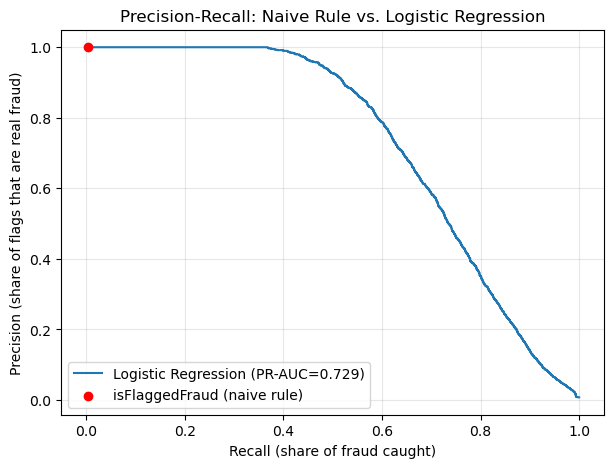

In [6]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score_lr)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Logistic Regression (PR-AUC={lr_result['pr_auc']:.3f})")
plt.scatter(
    [baseline_result["recall"]], [baseline_result["precision"]],
    color="red", zorder=5, label="isFlaggedFraud (naive rule)",
)
plt.xlabel("Recall (share of fraud caught)")
plt.ylabel("Precision (share of flags that are real fraud)")
plt.title("Precision-Recall: Naive Rule vs. Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [7]:
comparison_table = pd.DataFrame(results).set_index("model").round(4)
comparison_table


,precision,recall,f1,pr_auc
model,,,,
isFlaggedFraud (naive rule),1.0000,0.0031,0.0061,0.0107
Logistic Regression (balanced),0.2225,0.8598,0.3535,0.7289


## Summary

| | Precision | Recall | Take-away |
|---|---|---|---|
| **Naive rule** | High-ish, but few flags | Very low | Misses almost all fraud by design |
| **Logistic Regression** | Lower | Much higher | Catches far more fraud, but flags more legitimate transactions too |

Logistic Regression already beats the naive baseline by a wide margin on
recall and PR-AUC — but it's a linear model, and fraud patterns here (balance
mismatches, account behavior interactions) are unlikely to be purely linear.

**Next:** [04_advanced_modeling.ipynb](04_advanced_modeling.ipynb) brings in
Random Forest and XGBoost, compares three different ways of handling class
imbalance side by side, tunes the decision threshold in business terms, and
builds a separate model restricted to information available *before* a
transaction completes — the most important finding in this project for a
real-time production system.
